# Блок 7. Основы искусственного интеллекта и машинного обучения
# Занятие 3. Линейная регрессия

## Что изучаем

Линейная регрессия — первый и самый важный алгоритм машинного обучения.

Она используется для прогнозирования числовых значений:

- стоимости квартиры;
- продаж магазина;
- расходов компании;
- температуры;
- потребления энергии.

## Идея алгоритма

Модель пытается найти зависимость:

y = a*x + b

где:

- x — признак;
- y — прогноз;
- a — коэффициент;
- b — смещение.

## Метрики качества

### MAE
Средняя абсолютная ошибка.

### MSE
Средняя квадратичная ошибка.

### RMSE
Корень из MSE.

### R²
Коэффициент детерминации.

Чем ближе R² к 1, тем лучше.

## Связь с дипломом

Линейная регрессия часто используется как первая модель для:

- прогнозирования продаж;
- недвижимости;
- финансового анализа;
- аналитики клиентов.


Сначала изучите SOLVED ноутбук, затем выполните TODO самостоятельно.

## Ячейка 1. Загрузка датасета

### Алгоритм
Используем California Housing.

In [10]:
import pandas as pd

from notebooks.block7_lesson01_intro_ml_todo import prediction

url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"
df: pd.DataFrame = pd.read_csv(url)

print(df.columns.tolist())

print(df.shape)
print(df.describe())

assert len(df) > 1000


['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']
(20640, 10)
          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.585558   2181.615252   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1447.750000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.010000     37.710000           37.000000   3148.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  median_income  \
count    20433.000000  20640.000000  20640.000000   20640.000000   
mean       537.870553   1425.476744    499.53

## Ячейка 2. Подготовка данных

### Алгоритм
Выбираем признаки и цель.

In [3]:
feature_cols = ["median_income", "households", "population"]
target_col = "median_house_value"

data = df[[*feature_cols, target_col]].dropna()

X = data[feature_cols]
y = data[target_col]

assert len(X) == len(y)


## Ячейка 3. Разделение данных

### Алгоритм
Train/Test split.

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

n = len(X)
assert len(X_train) + len(X_test) == n
assert abs(len(X_test) / n - 0.2) < 1e-9

## Ячейка 4. Масштабирование

### Алгоритм
StandardScaler.

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

assert X_train_scaled.shape[0] == len(X_train)

## Ячейка 5. Обучение модели

### Алгоритм
LinearRegression.

In [22]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

assert model is not None

## Ячейка 6. Коэффициенты модели

### Алгоритм
Изучаем параметры модели.

In [25]:
for name, coef in zip(X.columns, model.coef_):
    print(name, round(coef, 2))

print("Intercept", round(model.intercept_, 2))

assert len(model.coef_) == 3

median_income 79385.6
households 53138.66
population -51557.88
Intercept 207194.69


## Ячейка 7. Прогнозирование

### Алгоритм
Делаем прогноз.

In [27]:
predictions = model.predict(X_test_scaled)

print(predictions[:5])

assert len(predictions) == len(y_test)

[ 97393.94544388 156373.77991327 260356.90587637 271278.39877611
 207140.84121071]


## Ячейка 8. Метрики качества

### Алгоритм
MAE MSE RMSE R2.

In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("MAE", mae)
print("MSE", mse)
print("RMSE", rmse)
print("R2", r2)

assert r2 > 0


MAE 61084.394890848045
MSE 6530288819.667245
RMSE 80810.20244787935
R2 0.5016602504941976


## Ячейка 9. Визуализация

### Алгоритм
Сравнение факта и прогноза.

Text(0.5, 1.0, 'Линейная регрессия')

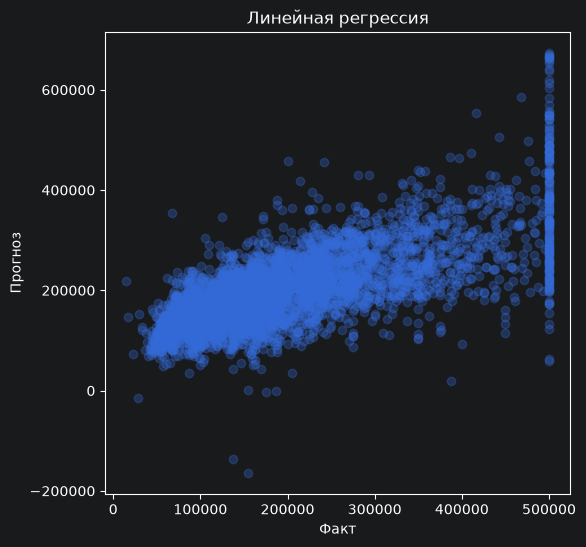

In [29]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.scatter(y_test, predictions, alpha=0.3)
plt.xlabel("Факт")
plt.ylabel("Прогноз")
plt.title("Линейная регрессия")


## Ячейка 10. Мини-проект

### Алгоритм
Формируем отчет.

In [ ]:

report={
    "rows":len(data),
    "features":len(X.columns),
    "MAE":round(mae,2),
    "RMSE":round(rmse,2),
    "R2":round(r2,3)
}

print(report)

assert report["features"]==3
